# Heart Rate Interval Segmentation

Detects workout interval boundaries using only HR data.

**Just run all cells from top to bottom!**

## 1. Install Dependencies (Run Once)

In [19]:
#!pip install numpy pandas scikit-learn xgboost scipy matplotlib seaborn --break-system-packages

## 2. Imports

In [20]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # For GPU determinism

print("✓ Imports complete")

✓ Imports complete


## 3. Configuration

In [21]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 30
    medium_window: int = 60
    long_window: int = 120
    
    # Model
    model_type: str = "xgboost"  # or "random_forest"
    xgb_max_depth: int = 8
    xgb_n_estimators: int = 300
    xgb_learning_rate: float = 0.05
    xgb_scale_pos_weight: float = 50.0
    
    # Post-processing
    peak_distance: int = 30 #minimum time between detected interval boundaries
    peak_prominence: float = 0.1
    smooth_sigma: float = 5.0 #smoothing for transitions

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 4. Your Data Configuration

In [22]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all",
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2']
  Test sessions: 11


## 5. Feature Engineering Functions

In [23]:
def create_hr_features(df: pd.DataFrame, config: Config) -> pd.DataFrame:
    """Create rich feature set from heart rate time series."""
    features = pd.DataFrame(index=df.index)
    
    hr = df['heart_rate'].values
    
    # Smoothed HR at different scales (Average HR over past [15s + future 15s])
    features['hr_raw'] = hr
    features['hr_smooth_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).mean()
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()
    
    # Derivatives - rate of change
    features['hr_diff_1s'] = df['heart_rate'].diff(1)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)
    features['hr_accel'] = features['hr_diff_1s'].diff(1) #change in rate of change
    
    # Rolling statistics - short window
    features['hr_std_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).std()
    features['hr_min_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).min()
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()
    features['hr_range_short'] = features['hr_max_short'] - features['hr_min_short']
    
    # Rolling statistics - medium window
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    
    # Relative features #How far current HR is from short-term average
    features['hr_vs_short_baseline'] = hr - features['hr_smooth_short']
    features['hr_vs_medium_baseline'] = hr - features['hr_smooth_medium']
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']
    
    # Trend indicators #Trend Indicators (Binary flags)
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)
    features['hr_decreasing'] = (features['hr_diff_10s'] < 0).astype(int)
    features['hr_stable'] = (features['hr_diff_10s'].abs() < 1).astype(int)
    
    # Lagged features
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_60s'] = df['heart_rate'].shift(60)
    features['hr_lag_90s'] = df['heart_rate'].shift(90)
    
    # Forward looking
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)
    
    # Change #Difference between 60s ahead and 60s ago (120s total span)
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - features['hr_lag_60s']
    
    # Clean up
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)
    
    # Clip outliers
    for col in features.columns:
        if features[col].std() > 0:
            q99 = features[col].quantile(0.99)
            q01 = features[col].quantile(0.01)
            features[col] = features[col].clip(q01, q99)
    
    return features

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 6. Post-Processing Functions

In [24]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""
    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)
    
    # ALWAYS START WITH INDEX 0 (first timestamp is always a boundary)
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1  # We need to find (n-1) more peaks

    # Find peaks (excluding index 0 region to avoid duplicates)
    peaks, properties = find_peaks(
        probs_smooth[config.peak_distance:],  # Start search after first peak_distance
        distance=config.peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + config.peak_distance  # Adjust indices back

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest (plus index 0)
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[config.peak_distance:], distance=config.peak_distance)
        peaks = peaks + config.peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - take N-1 highest probability points (excluding first peak_distance)
        top_indices = np.argsort(probs_smooth[config.peak_distance:])[-n_remaining * 3:][::-1] + config.peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= config.peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

print("✓ Post-processing functions defined")

✓ Post-processing functions defined


## 7. Evaluation Functions

In [25]:
def evaluate_with_tolerance_asymmetric(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 3,
                                       tolerance_after: int = 7) -> Dict:
    """
    Evaluate predictions with asymmetric time tolerance.
    Allows 3 seconds before and 7 seconds after the true boundary.
    Uses F_beta score with beta=2 (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth (within asymmetric window)
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            # Check if prediction is within [-3s, +7s] of ground truth
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break  # Count this prediction only once

    # Match ground truth to predictions (within asymmetric window)
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break  # Count this GT only once

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    # Standard precision and recall
    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0

    # F_beta score with beta=2 (weighs recall 2x more than precision)
    beta = 2
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error for matched predictions
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,  # This is your 2:1 recall-weighted F-score
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 8. Data Loading

In [26]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 13610691264_1x_Crescendo
✓ Athlete12 - 11838948742_3006_row
✓ Athlete12 - 13618782252_3x5
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 14260930602_3x1010_SubThr
✓ Athlete12 - 14313279747_Vernunft_verliert_
✓ Athlete12 - 14156450361_On_a_mission
✓ Athlete12 - 14374019349_Uff
✓ Athlete12 - 13363035398_SGAktiv
✓ Athlete12 - 13300350440_W_Up
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 14114545767_Dampfnudel
✓ Athlete12 - 13688068283_Luftpresser
✓ Athlete12 - 13974345688_Nochmaaaal
✓ Athlete12 - 13662882990_Heldentod
✓ Athlete12 - 11791568584_
✓ Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
✓ Athlete12 - 13643807487_Nachfitten
✓ Athlete12 - 13280559542_Warm_up_rowing
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 14125110656_Vallah_isch_balla
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 12846

## 9. Prepare Train/Test Data

In [27]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

for (athlete, session), df in hr_session_data.items():
    # Create features
    features_df = create_hr_features(df, CONFIG)
    y = df['manual_timestamp_numerical'].values
    X = features_df.values
    
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue
    
    session_info = {
        'athlete': athlete,
        'session': session,
        'X': X,
        'y': y,
        'n_intervals': y.sum(),
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df  # Keep original for plotting
    }
    
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
    else:
        train_sessions.append(session_info)

# Combine training data
X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Normalize test data
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

✓ Dataset prepared:
   Training sessions: 60
   Test sessions: 11
   Training samples: 186,289 (618 positive)
   Features: 28


## 10. Train Model

In [28]:
print(f"\n🏋️  Training {CONFIG.model_type} model...")

if CONFIG.model_type == "xgboost":
    model = xgb.XGBClassifier(
        max_depth=CONFIG.xgb_max_depth,
        n_estimators=CONFIG.xgb_n_estimators,
        learning_rate=CONFIG.xgb_learning_rate,
        scale_pos_weight=CONFIG.xgb_scale_pos_weight,
        min_child_weight=5,  # NEW - reduce overfitting
        gamma=0.2,            # NEW - require meaningful splits
        subsample=0.8,        # NEW - use 80% of data per tree
        colsample_bytree=0.8, # NEW - use 80% of features per tree
        random_state=CONFIG.random_seed,
        tree_method='hist',
        eval_metric='logloss',
        n_jobs=1,           # Single threaded
        nthread=1,          # Deprecated but sometimes needed
        deterministic_histogram=True  # NEW - force deterministic
    )
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=CONFIG.random_seed,
        n_jobs=-1
    )

model.fit(X_train, y_train)
print("✓ Model trained!")




🏋️  Training xgboost model...
✓ Model trained!


In [29]:
# save model
#import joblib

# Save each to a DIFFERENT file
#joblib.dump(model, 'xgboost_model.pkl')
#joblib.dump(scaler, 'xgboost_scaler.pkl')
#joblib.dump(CONFIG, 'xgboost_config.pkl')
#print("✓ Model, scaler, and config saved!")

## 11. Evaluate on Test Sessions

In [30]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']
    
    # Get probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Post-process
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1
    
    # Evaluate
    metrics = evaluate_with_tolerance_asymmetric(y_true, y_pred)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']
    
    test_results.append(metrics)
    
    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

# Overall stats
avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-3s & +7s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)


📈 Evaluating on test sessions...

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.727 | P: 0.727 | R: 0.727 | Error: 3.7s
   Intervals: 11/11

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 4.8s
   Intervals: 11/11

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.444 | P: 0.444 | R: 0.444 | Error: 35.2s
   Intervals: 9/9

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 1.7s
   Intervals: 3/3

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.833 | P: 0.833 | R: 0.833 | Error: 2.8s
   Intervals: 12/12

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.222 | P: 0.222 | R: 0.222 | Error: 31.0s
   Intervals: 9/9

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.500 | P: 0.500 | R: 0.500 | Error: 30.2s
   Intervals: 10/10

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.222 | P: 0.222 | R: 0.222 | E

In [31]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    # Get probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]

    # Post-process
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate
    metrics = evaluate_with_tolerance_asymmetric(y_true, y_pred, 10, 10)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']

    test_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

# Overall stats
avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)


📈 Evaluating on test sessions...

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 3.7s
   Intervals: 11/11

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 4.8s
   Intervals: 11/11

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.556 | P: 0.556 | R: 0.556 | Error: 35.2s
   Intervals: 9/9

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 1.7s
   Intervals: 3/3

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 2.8s
   Intervals: 12/12

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.667 | P: 0.667 | R: 0.667 | Error: 31.0s
   Intervals: 9/9

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.700 | P: 0.700 | R: 0.700 | Error: 30.2s
   Intervals: 10/10

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.556 | P: 0.556 | R: 0.556 | E

## 12. Feature Importance


🔝 Top 10 Most Important Features:
   hr_raw                         0.0801
   hr_increasing                  0.0699
   hr_vs_long_baseline            0.0555
   hr_max_short                   0.0513
   hr_vs_medium_baseline          0.0513
   hr_max_medium                  0.0511
   hr_std_medium                  0.0443
   hr_change_past_to_future       0.0406
   hr_min_short                   0.0379
   hr_std_short                   0.0328


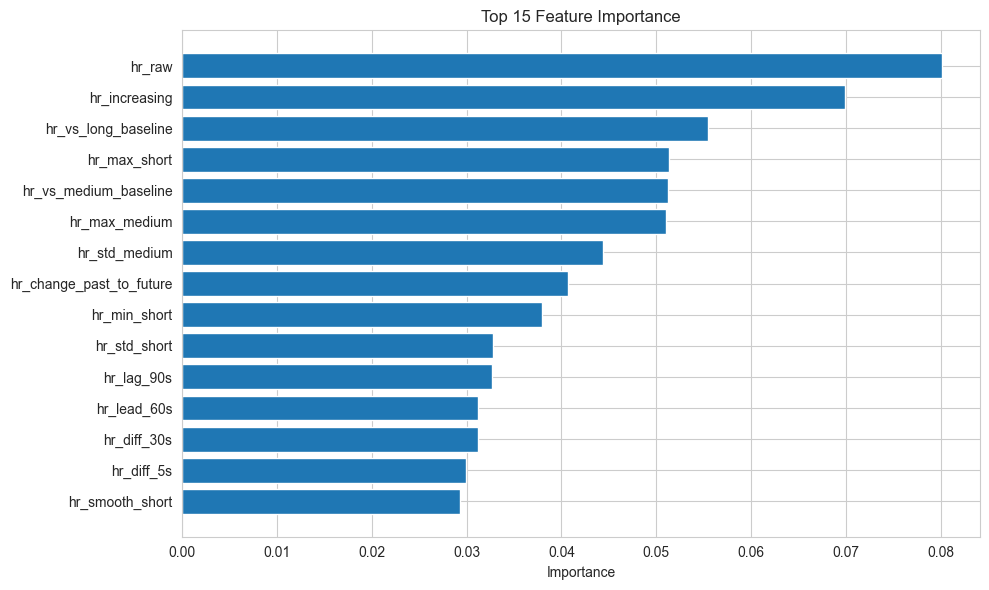

In [32]:
if hasattr(model, 'feature_importances_'):
    feature_names = test_sessions_data[0]['feature_names']
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔝 Top 10 Most Important Features:")
    for idx, row in importance_df.head(10).iterrows():
        print(f"   {row['feature']:30s} {row['importance']:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. Visualize All Test Sessions

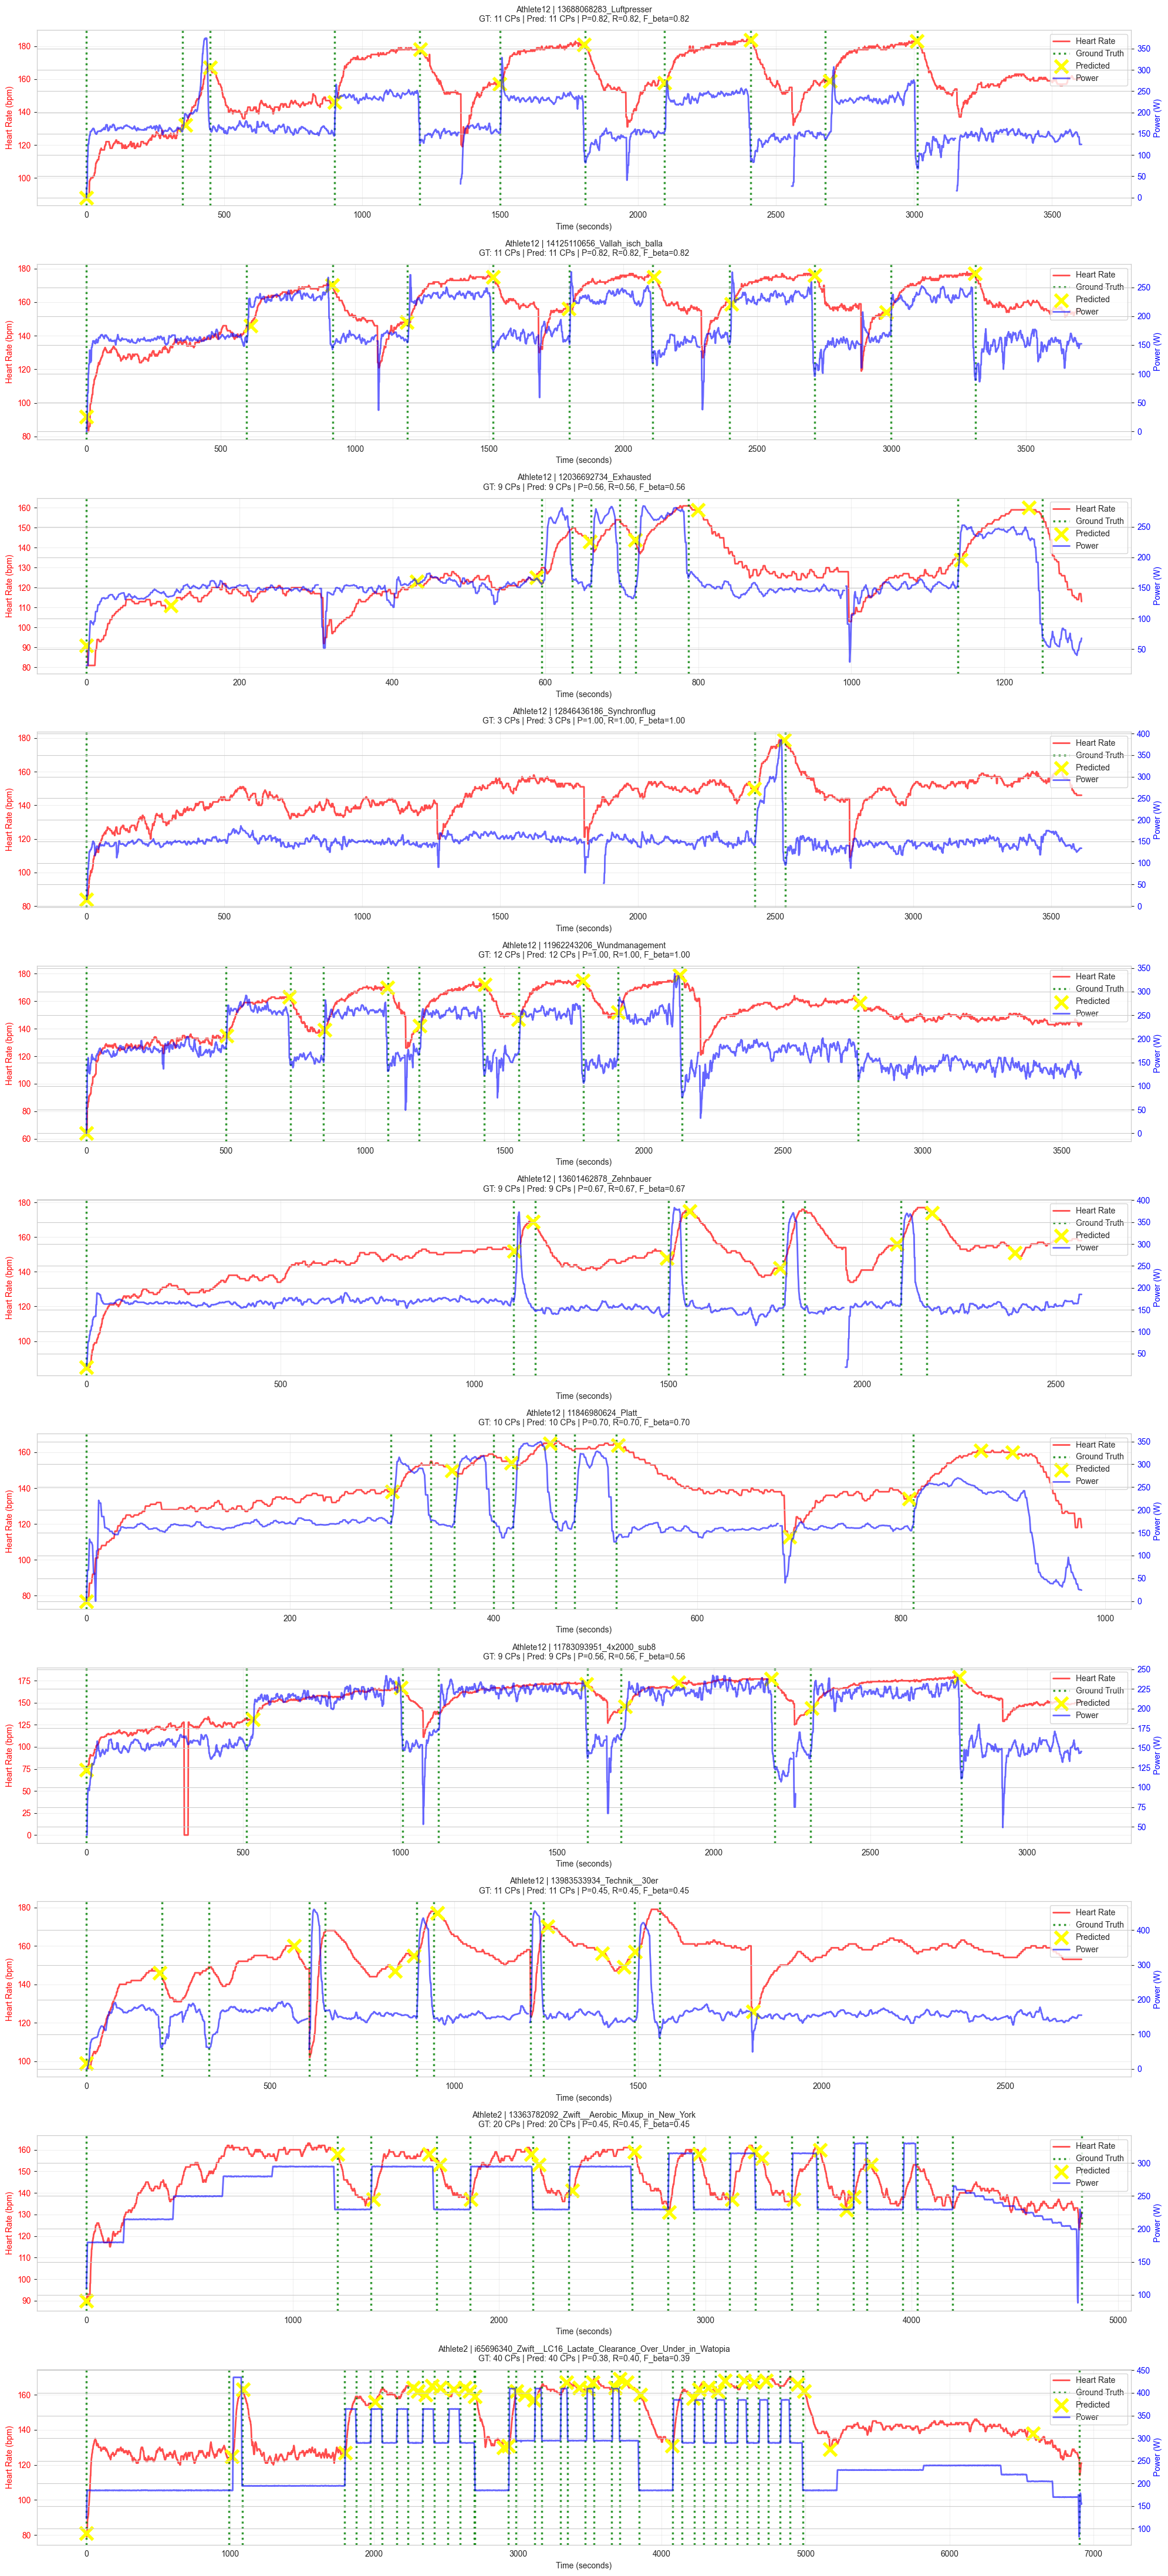

In [33]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics

In [35]:
# Evaluate with details
results_detailed = []

for s in test_sessions_data:
    proba = model.predict_proba(s['X'])[:, 1]
    peaks = detect_peaks_with_constraint(proba, s['n_intervals'], CONFIG)
    pred = np.zeros(len(proba), dtype=int)
    pred[peaks] = 1

    m = evaluate_with_tolerance_asymmetric(s['y'], pred, 3, 7)

    results_detailed.append({
        'athlete': s['athlete'],
        'session': s['session'],
        'sport': 'rowing' if s['athlete'] == 'Athlete12' else 'biking',
        'n_intervals': s['n_intervals'],
        'duration_sec': len(s['y']),
        'duration_min': len(s['y']) / 60,
        'f_beta': m['f_beta'],
        'precision': m['precision'],
        'recall': m['recall'],
        'n_true': m['n_true'],
        'n_pred': m['n_pred'],
        'mean_error_sec': m['mean_error_sec']
    })

df_results = pd.DataFrame(results_detailed)

# Sort by F_beta to see best and worst
df_sorted = df_results.sort_values('f_beta', ascending=False)

print("="*80)
print("XGBOOST PERFORMANCE BY SESSION")
print("="*80)
print(df_sorted.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(df_results[['f_beta', 'precision', 'recall', 'mean_error_sec']].describe())

XGBOOST PERFORMANCE BY SESSION
  athlete                                                       session  sport  n_intervals  duration_sec  duration_min   f_beta  precision   recall  n_true  n_pred  mean_error_sec
Athlete12                                      12846436186_Synchronflug rowing            3          3611     60.183333 1.000000   1.000000 1.000000       3       3        1.666667
Athlete12                                    11962243206_Wundmanagement rowing           12          3572     59.533333 0.833333   0.833333 0.833333      12      12        2.750000
Athlete12                                 14125110656_Vallah_isch_balla rowing           11          3709     61.816667 0.818182   0.818182 0.818182      11      11        4.818182
Athlete12                                       13688068283_Luftpresser rowing           11          3608     60.133333 0.727273   0.727273 0.727273      11      11        3.727273
Athlete12                                            11846980624

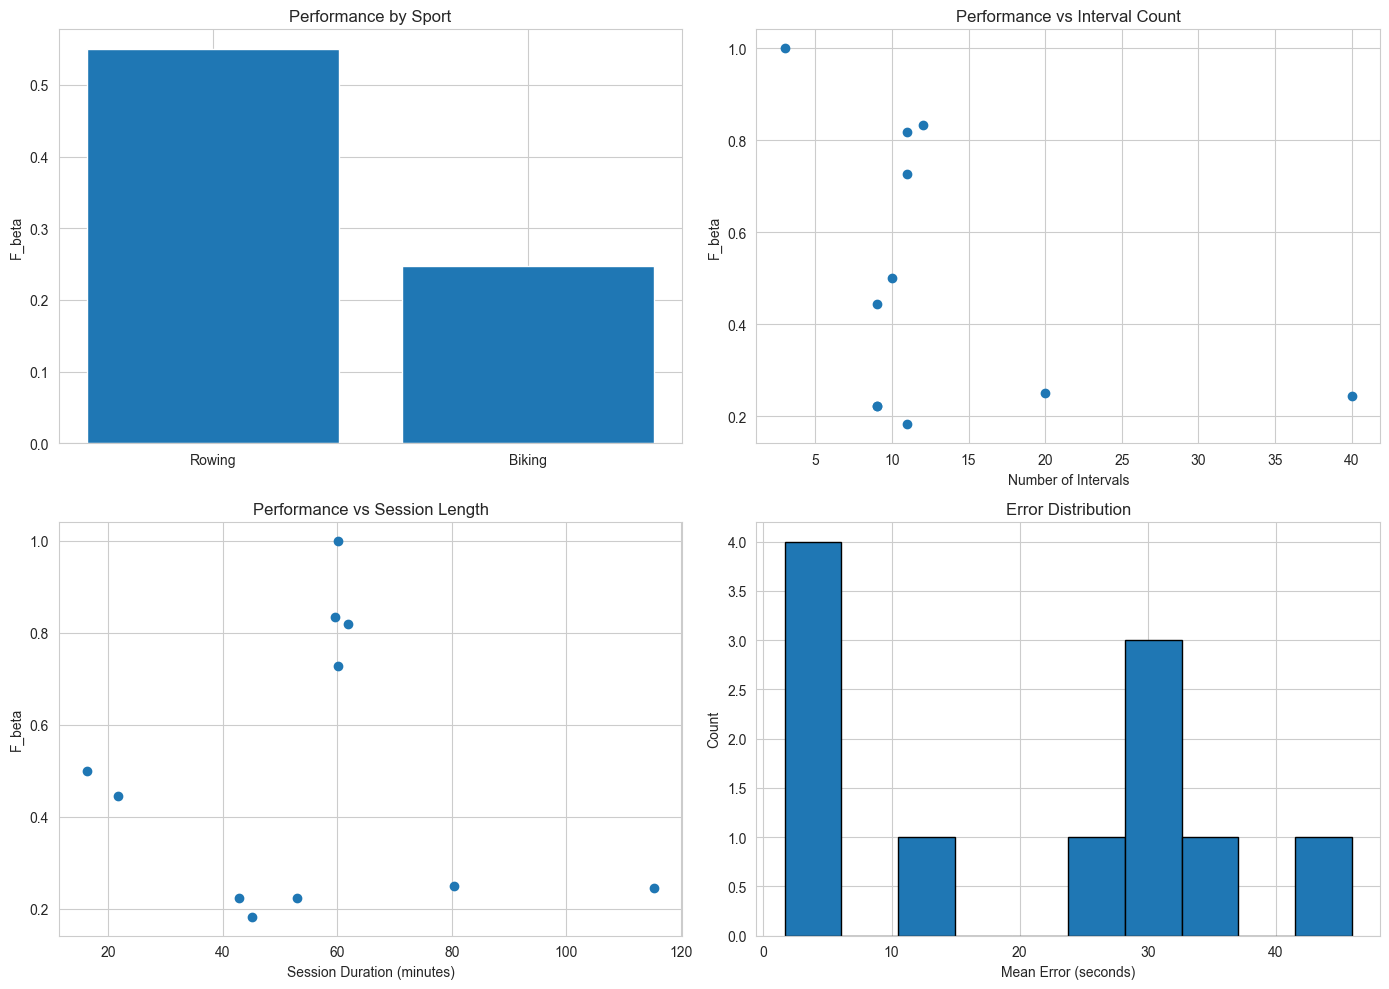

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F_beta by sport
axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

# 2. F_beta vs number of intervals
axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

# 3. F_beta vs session duration
axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

# 4. Error distribution
axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()